In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Block 2 — Import all libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This just makes plots look clean
plt.style.use('seaborn-v0_8')
print("All libraries loaded successfully ✅")

All libraries loaded successfully ✅


In [6]:
# Block 3 — Load the dataset
# Update the path below to wherever you saved cs-training.csv in your Drive
df = pd.read_csv('/content/drive/MyDrive/Credit_Risk_Project/cs-training.csv')

print("Shape of data:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of data: (150000, 12)

First 5 rows:


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
# Block 4 — See all columns and their data types
print(df.columns.tolist())
print("\n")
df.info()

['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                 

In [8]:
# Block 5 — Missing value analysis
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent
})

# Only show columns that actually have missing values
print(missing_df[missing_df['Missing Count'] > 0])

                    Missing Count  Missing Percentage
MonthlyIncome               29731           19.820667
NumberOfDependents           3924            2.616000


In [9]:
# Block 6 — How many defaulters vs non-defaulters do we have?
print("Target variable distribution:")
print(df['SeriousDlqin2yrs'].value_counts())
print("\nIn percentages:")
print(df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100)

Target variable distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In percentages:
SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


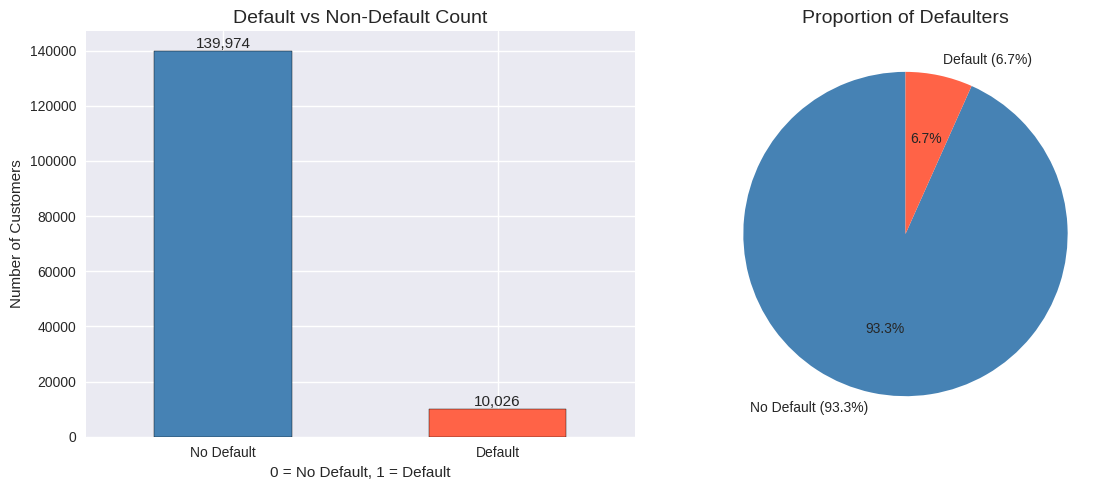

Chart saved! ✅


In [10]:
# Block 7 — Visualize class imbalance
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 - Count plot
df['SeriousDlqin2yrs'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
axes[0].set_title('Default vs Non-Default Count', fontsize=14)
axes[0].set_xlabel('0 = No Default, 1 = Default')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(['No Default', 'Default'], rotation=0)

# Add count labels on bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Plot 2 - Pie chart
axes[1].pie(
    df['SeriousDlqin2yrs'].value_counts(),
    labels=['No Default (93.3%)', 'Default (6.7%)'],
    colors=['steelblue', 'tomato'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proportion of Defaulters', fontsize=14)

plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved! ✅")

In [11]:
# Block 8 — Basic statistics of all columns
df.drop('Unnamed: 0', axis=1).describe().round(2)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


In [12]:
# Block 8b — Drop the useless column permanently
df = df.drop('Unnamed: 0', axis=1)
print("Column dropped. Remaining columns:", df.shape[1])

Column dropped. Remaining columns: 11


In [13]:
# Block 9a — How many customers have age = 0?
print("Customers with age = 0:", (df['age'] == 0).sum())

# Block 9b — The 98 problem — how many rows have exactly 98?
cols_98 = ['NumberOfTime30-59DaysPastDueNotWorse',
           'NumberOfTimes90DaysLate',
           'NumberOfTime60-89DaysPastDueNotWorse']

for col in cols_98:
    print(f"{col} → count of 98s: {(df[col] == 98).sum()}")

# Block 9c — Distribution of RevolvingUtilization
print("\nRevolvingUtilization > 1 (should be impossible):",
      (df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum())

# Block 9d — MonthlyIncome quick look
print("\nMonthlyIncome above 1 lakh/month:",
      (df['MonthlyIncome'] > 100000).sum())

Customers with age = 0: 1
NumberOfTime30-59DaysPastDueNotWorse → count of 98s: 264
NumberOfTimes90DaysLate → count of 98s: 264
NumberOfTime60-89DaysPastDueNotWorse → count of 98s: 264

RevolvingUtilization > 1 (should be impossible): 3321

MonthlyIncome above 1 lakh/month: 70


In [14]:
# Block 10a — Verify the 264 are same customers
mask = ((df['NumberOfTime30-59DaysPastDueNotWorse'] == 98) |
        (df['NumberOfTimes90DaysLate'] == 98) |
        (df['NumberOfTime60-89DaysPastDueNotWorse'] == 98))
print("Total unique rows with any 98:", mask.sum())

Total unique rows with any 98: 264


In [15]:
# Block 10b — Remove age = 0 and the 98 rows
print("Shape before cleaning:", df.shape)

# Remove age = 0
df = df[df['age'] != 0]

# Remove rows with 98 in any late payment column
df = df[df['NumberOfTime30-59DaysPastDueNotWorse'] != 98]
df = df[df['NumberOfTimes90DaysLate'] != 98]
df = df[df['NumberOfTime60-89DaysPastDueNotWorse'] != 98]

print("Shape after removing bad rows:", df.shape)
print("Rows removed:", 150000 - df.shape[0])

Shape before cleaning: (150000, 11)
Shape after removing bad rows: (149735, 11)
Rows removed: 265


In [16]:
# Block 10c — Cap RevolvingUtilization at 1.0
# WHY CAP instead of delete? Because 3321 rows is too many to throw away.
# Capping means — anything above 1, just set it to 1.
# It's wrong data but the customer still exists, so we keep the row.

df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.0)

print("Max RevolvingUtilization after capping:",
      df['RevolvingUtilizationOfUnsecuredLines'].max())

Max RevolvingUtilization after capping: 1.0


In [17]:
# Block 10d — Cap MonthlyIncome at 99th percentile
# WHY 99th percentile? Because we don't want to lose real high earners
# but we also don't want one person earning 30 lakhs skewing everything.
# 99th percentile = we only cap the top 1% most extreme values.

income_cap = df['MonthlyIncome'].quantile(0.99)
print("Capping MonthlyIncome at:", income_cap)

df['MonthlyIncome'] = df['MonthlyIncome'].clip(upper=income_cap)
print("Max MonthlyIncome after capping:", df['MonthlyIncome'].max())

Capping MonthlyIncome at: 25000.0
Max MonthlyIncome after capping: 25000.0


In [18]:
# Block 11 — Fill missing values with median
# WHY MEDIAN? Because both MonthlyIncome and NumberOfDependents
# are skewed — median represents the typical customer better than mean

# Check medians first so we know what we're filling with
print("MonthlyIncome median:", df['MonthlyIncome'].median())
print("NumberOfDependents median:", df['NumberOfDependents'].median())

# Now fill
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

# Verify — should show 0 missing now
print("\nMissing values after filling:")
print(df.isnull().sum())

MonthlyIncome median: 5400.0
NumberOfDependents median: 0.0

Missing values after filling:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [20]:
# Block 12 — Save cleaned data
df.to_csv('/content/drive/MyDrive/Credit_Risk_Project/cleaned_data.csv', index=False)
print("Cleaned data saved successfully ✅")
print("Final shape:", df.shape)

Cleaned data saved successfully ✅
Final shape: (149735, 11)


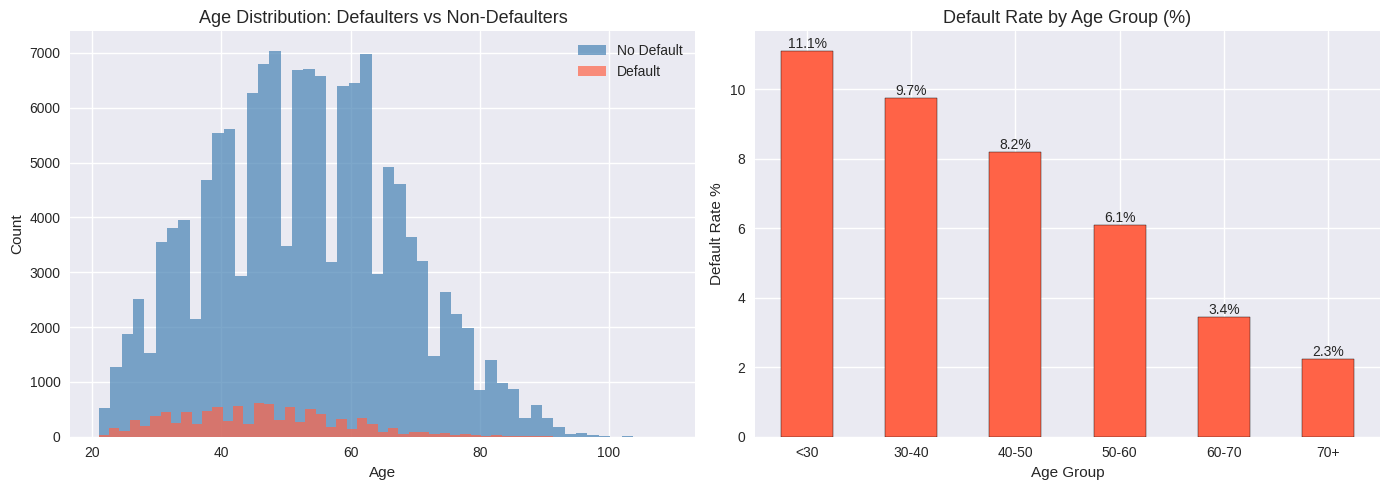

In [21]:
# Block 13 — Age distribution by default status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Age distribution for defaulters vs non-defaulters
df[df['SeriousDlqin2yrs'] == 0]['age'].hist(
    bins=50, ax=axes[0], alpha=0.7, color='steelblue', label='No Default'
)
df[df['SeriousDlqin2yrs'] == 1]['age'].hist(
    bins=50, ax=axes[0], alpha=0.7, color='tomato', label='Default'
)
axes[0].set_title('Age Distribution: Defaulters vs Non-Defaulters', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2 - Default rate by age group
# First create age groups
df['AgeGroup'] = pd.cut(df['age'],
                         bins=[0, 30, 40, 50, 60, 70, 110],
                         labels=['<30', '30-40', '40-50', '50-60', '60-70', '70+'])

default_by_age = df.groupby('AgeGroup', observed=True)['SeriousDlqin2yrs'].mean() * 100

default_by_age.plot(kind='bar', ax=axes[1],
                    color='tomato', edgecolor='black')
axes[1].set_title('Default Rate by Age Group (%)', fontsize=13)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Default Rate %')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Add percentage labels on bars
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('age_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()

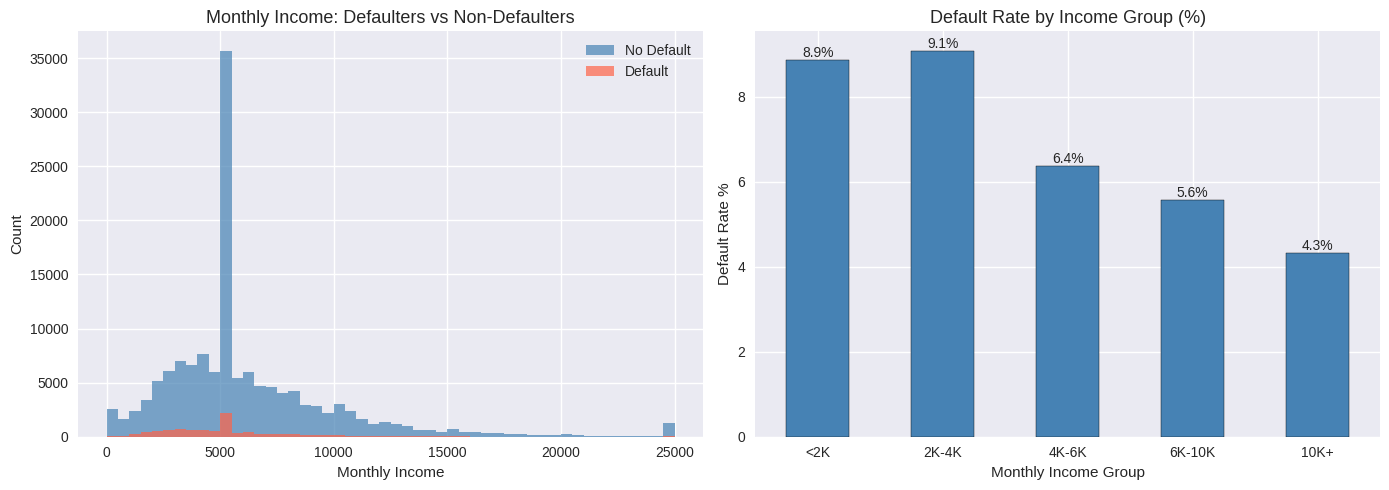

In [22]:
# Block 14 — Monthly Income vs Default Rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Income distribution by default status
df[df['SeriousDlqin2yrs'] == 0]['MonthlyIncome'].hist(
    bins=50, ax=axes[0], alpha=0.7, color='steelblue', label='No Default'
)
df[df['SeriousDlqin2yrs'] == 1]['MonthlyIncome'].hist(
    bins=50, ax=axes[0], alpha=0.7, color='tomato', label='Default'
)
axes[0].set_title('Monthly Income: Defaulters vs Non-Defaulters', fontsize=13)
axes[0].set_xlabel('Monthly Income')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2 - Default rate by income group
df['IncomeGroup'] = pd.cut(df['MonthlyIncome'],
                            bins=[0, 2000, 4000, 6000, 10000, 25001],
                            labels=['<2K', '2K-4K', '4K-6K', '6K-10K', '10K+'])

default_by_income = df.groupby('IncomeGroup', observed=True)['SeriousDlqin2yrs'].mean() * 100

default_by_income.plot(kind='bar', ax=axes[1],
                       color='steelblue', edgecolor='black')
axes[1].set_title('Default Rate by Income Group (%)', fontsize=13)
axes[1].set_xlabel('Monthly Income Group')
axes[1].set_ylabel('Default Rate %')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('income_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()

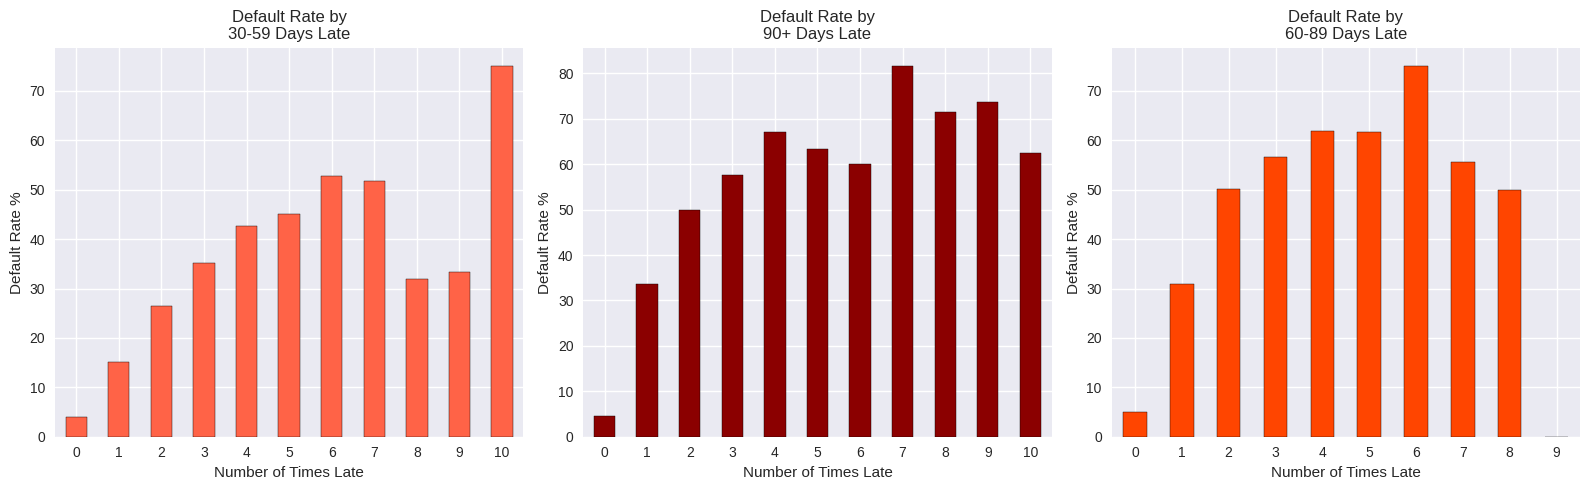

In [23]:
# Block 15 — Late payments vs Default Rate
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

titles = ['30-59 Days Late', '90+ Days Late', '60-89 Days Late']
colors = ['tomato', 'darkred', 'orangered']

for i, (col, title, color) in enumerate(zip(late_cols, titles, colors)):
    # Cap at 10 for visualization (values above 10 are very rare)
    temp = df[df[col] <= 10].copy()
    default_rate = temp.groupby(col)['SeriousDlqin2yrs'].mean() * 100

    default_rate.plot(kind='bar', ax=axes[i], color=color, edgecolor='black')
    axes[i].set_title(f'Default Rate by\n{title}', fontsize=12)
    axes[i].set_xlabel('Number of Times Late')
    axes[i].set_ylabel('Default Rate %')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('late_payments_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()

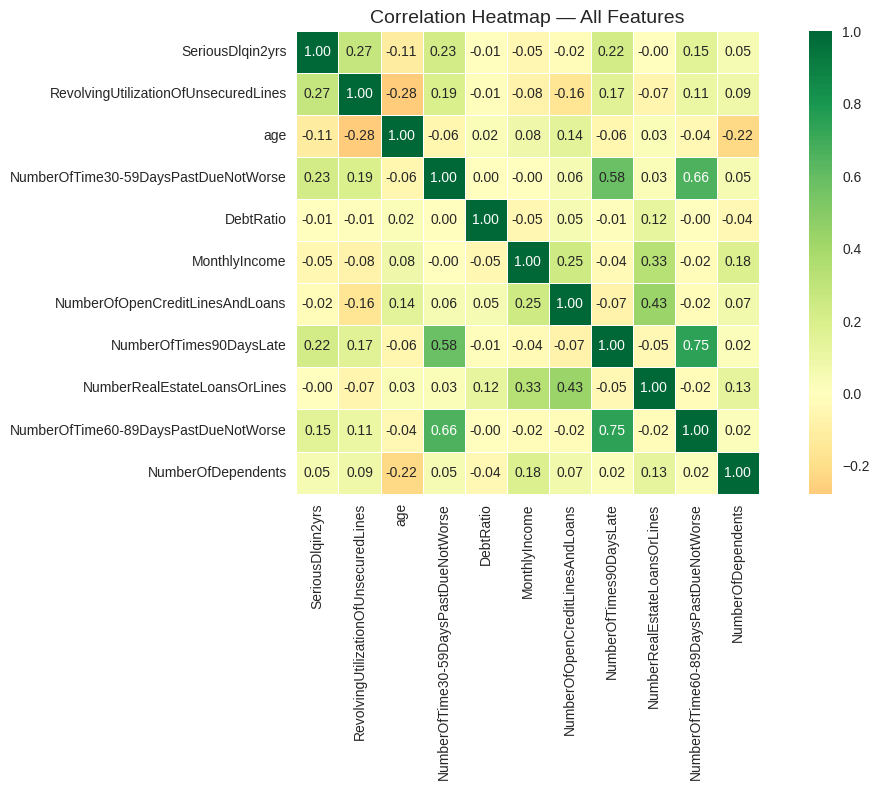

In [24]:
# Block 16 — Correlation Heatmap
plt.figure(figsize=(12, 8))

# Calculate correlations
corr_matrix = df.drop(['AgeGroup', 'IncomeGroup'], axis=1).corr()

# Draw heatmap
sns.heatmap(corr_matrix,
            annot=True,          # Show numbers inside boxes
            fmt='.2f',           # Round to 2 decimal places
            cmap='RdYlGn',       # Red=negative, Yellow=zero, Green=positive
            center=0,            # Center the color scale at 0
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap — All Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
# Block 17a — Create all engineered features

# Feature 1 - Total late payments across all categories
df['total_late_payments'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)

# Feature 2 - Debt pressure relative to income
df['debt_to_income'] = df['DebtRatio'] / (df['MonthlyIncome'] + 1)

# Feature 3 - How much income available per dependent
df['income_per_dependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

# Feature 4 - High credit utilization flag
df['high_utilization'] = (df['RevolvingUtilizationOfUnsecuredLines'] > 0.75).astype(int)

# Feature 5 - Age and late payment interaction
df['age_risk_score'] = df['age'] * df['total_late_payments']

# Feature 6 - Loans relative to income (your idea!)
df['loans_to_income'] = df['NumberOfOpenCreditLinesAndLoans'] / (df['MonthlyIncome'] + 1)

print("All features created ✅")
print("Total columns now:", df.shape[1])

All features created ✅
Total columns now: 19


In [26]:
# Block 17b — Check if new features are actually better predictors
# We'll compare correlation of NEW features vs ORIGINAL weak features

original_features = ['DebtRatio', 'MonthlyIncome',
                     'NumberOfDependents', 'NumberOfOpenCreditLinesAndLoans']

new_features = ['total_late_payments', 'debt_to_income',
                'income_per_dependent', 'high_utilization',
                'age_risk_score', 'loans_to_income']

target = 'SeriousDlqin2yrs'

print("=" * 50)
print("ORIGINAL FEATURES — Correlation with Default:")
print("=" * 50)
for col in original_features:
    corr = df[col].corr(df[target])
    print(f"{col:45s} → {corr:.4f}")

print("\n" + "=" * 50)
print("NEW ENGINEERED FEATURES — Correlation with Default:")
print("=" * 50)
for col in new_features:
    corr = df[col].corr(df[target])
    print(f"{col:45s} → {corr:.4f}")

ORIGINAL FEATURES — Correlation with Default:
DebtRatio                                     → -0.0071
MonthlyIncome                                 → -0.0472
NumberOfDependents                            → 0.0483
NumberOfOpenCreditLinesAndLoans               → -0.0244

NEW ENGINEERED FEATURES — Correlation with Default:
total_late_payments                           → 0.2312
debt_to_income                                → -0.0021
income_per_dependent                          → -0.0606
high_utilization                              → 0.2581
age_risk_score                                → 0.2626
loans_to_income                               → -0.0106


In [27]:
# Block 18 — Save dataset with engineered features
df.to_csv('/content/drive/MyDrive/Credit_Risk_Project/featured_data.csv', index=False)
print("Data with engineered features saved ✅")
print("Final shape:", df.shape)
print("\nAll columns:")
print(df.columns.tolist())

Data with engineered features saved ✅
Final shape: (149735, 19)

All columns:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'AgeGroup', 'IncomeGroup', 'total_late_payments', 'debt_to_income', 'income_per_dependent', 'high_utilization', 'age_risk_score', 'loans_to_income']


In [28]:
# Block 19 — Prepare final dataset for modeling

# Drop visualization columns — not needed for model
df = df.drop(['AgeGroup', 'IncomeGroup'], axis=1)

# Separate features (X) from target (y)
# X = everything the model uses to learn
# y = what the model is trying to predict

X = df.drop('SeriousDlqin2yrs', axis=1)  # All columns except target
y = df['SeriousDlqin2yrs']               # Only the target column

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())
print("\nTarget distribution:")
print(y.value_counts())

Features (X) shape: (149735, 16)
Target (y) shape: (149735,)

Feature columns: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'total_late_payments', 'debt_to_income', 'income_per_dependent', 'high_utilization', 'age_risk_score', 'loans_to_income']

Target distribution:
SeriousDlqin2yrs
0    139852
1      9883
Name: count, dtype: int64


In [29]:
# Block 20 — Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Features
    y,                  # Target
    test_size=0.2,      # 20% goes to test set
    random_state=42,    # Ensures same split every time you run
    stratify=y          # Maintains same 6.7% default ratio in both sets
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nDefault rate in training set:", y_train.mean().round(4))
print("Default rate in test set:", y_test.mean().round(4))

Training set size: (119788, 16)
Test set size: (29947, 16)

Default rate in training set: 0.066
Default rate in test set: 0.066


In [30]:
# Block 21 — Apply SMOTE to training data only
# Install if needed (should already be available in Colab)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Non-defaulters: {(y_train == 0).sum()}")
print(f"  Defaulters:     {(y_train == 1).sum()}")

print("\nAfter SMOTE:")
print(f"  Non-defaulters: {(y_train_smote == 0).sum()}")
print(f"  Defaulters:     {(y_train_smote == 1).sum()}")

print("\nNew training set size:", X_train_smote.shape)

Before SMOTE:
  Non-defaulters: 111882
  Defaulters:     7906

After SMOTE:
  Non-defaulters: 111882
  Defaulters:     111882

New training set size: (223764, 16)


In [31]:
# Block 22 — Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data ONLY — then transform both train and test
# WHY? Because we can't let test data influence our scaling
# That would be "data leakage" — a serious mistake
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete ✅")
print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)

Scaling complete ✅
Training set shape: (223764, 16)
Test set shape: (29947, 16)


LOGISTIC REGRESSION RESULTS
ROC-AUC Score: 0.8088

Classification Report:
              precision    recall  f1-score   support

  No Default       0.97      0.84      0.90     27970
     Default       0.20      0.58      0.30      1977

    accuracy                           0.82     29947
   macro avg       0.59      0.71      0.60     29947
weighted avg       0.92      0.82      0.86     29947



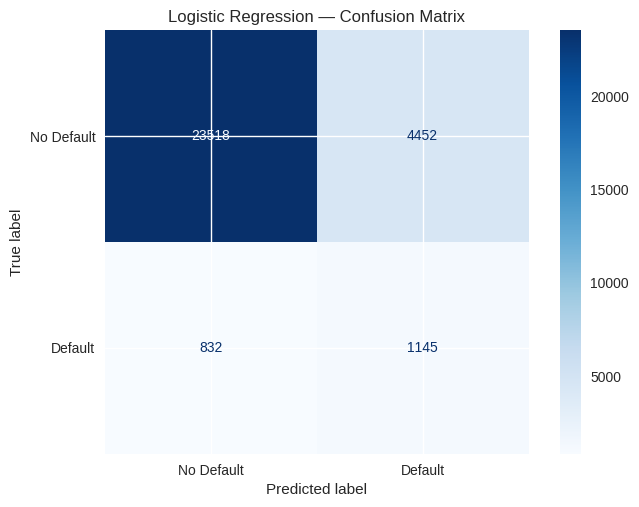

In [32]:
# Block 23 — Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_smote)

# Get predictions
# predict_proba gives probability scores between 0-1
# we take column [1] which is probability of DEFAULT
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_preds = lr_model.predict(X_test_scaled)

# Evaluate
lr_auc = roc_auc_score(y_test, lr_probs)
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"ROC-AUC Score: {lr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds,
      target_names=['No Default', 'Default']))

# Confusion Matrix
cm = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.savefig('lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Block 24 — Random Forest
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest... (this takes 1-2 minutes)")

rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 trees
    max_depth=10,          # Each tree can go 10 levels deep
    random_state=42,
    n_jobs=-1              # Use all CPU cores — makes it faster
)

rf_model.fit(X_train_smote, y_train_smote)

# Predictions
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_preds = rf_model.predict(X_test)

# Evaluate
rf_auc = roc_auc_score(y_test, rf_probs)
print("\n" + "=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"ROC-AUC Score: {rf_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds,
      target_names=['No Default', 'Default']))

Training Random Forest... (this takes 1-2 minutes)

RANDOM FOREST RESULTS
ROC-AUC Score: 0.8400

Classification Report:
              precision    recall  f1-score   support

  No Default       0.97      0.87      0.92     27970
     Default       0.25      0.61      0.36      1977

    accuracy                           0.86     29947
   macro avg       0.61      0.74      0.64     29947
weighted avg       0.92      0.86      0.88     29947



In [34]:
# Block 25 — XGBoost (run immediately after Random Forest)
from xgboost import XGBClassifier

print("Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=200,        # 200 trees
    max_depth=6,             # Each tree 6 levels deep
    learning_rate=0.1,       # How fast it learns
    scale_pos_weight=14,     # Tells XGBoost our data is imbalanced
                             # 14 = ratio of non-defaulters to defaulters
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)

xgb_model.fit(X_train_smote, y_train_smote)

# Predictions
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = xgb_model.predict(X_test)

# Evaluate
xgb_auc = roc_auc_score(y_test, xgb_probs)
print("\n" + "=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)
print(f"ROC-AUC Score: {xgb_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds,
      target_names=['No Default', 'Default']))

Training XGBoost...

XGBOOST RESULTS
ROC-AUC Score: 0.7993

Classification Report:
              precision    recall  f1-score   support

  No Default       0.98      0.52      0.68     27970
     Default       0.11      0.88      0.20      1977

    accuracy                           0.54     29947
   macro avg       0.55      0.70      0.44     29947
weighted avg       0.93      0.54      0.65     29947



In [35]:
# Block 26 — Compare all 3 models side by side
print("\n" + "=" * 50)
print("FINAL MODEL COMPARISON")
print("=" * 50)
print(f"Logistic Regression  → ROC-AUC: {lr_auc:.4f}")
print(f"Random Forest        → ROC-AUC: {rf_auc:.4f}")
print(f"XGBoost              → ROC-AUC: {xgb_auc:.4f}")
print("=" * 50)
print(f"Best Model: {'XGBoost' if xgb_auc > rf_auc else 'Random Forest'}")


FINAL MODEL COMPARISON
Logistic Regression  → ROC-AUC: 0.8088
Random Forest        → ROC-AUC: 0.8400
XGBoost              → ROC-AUC: 0.7993
Best Model: Random Forest


In [36]:
# Block 27 — XGBoost Tuned
xgb_model_v2 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,    # Slower learning = more careful
    subsample=0.8,         # Each tree uses 80% of data randomly
    colsample_bytree=0.8,  # Each tree uses 80% of features randomly
    # Removed scale_pos_weight — SMOTE already handled imbalance
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)

xgb_model_v2.fit(X_train_smote, y_train_smote)

# Predictions
xgb_probs_v2 = xgb_model_v2.predict_proba(X_test)[:, 1]
xgb_preds_v2 = xgb_model_v2.predict(X_test)

# Evaluate
xgb_auc_v2 = roc_auc_score(y_test, xgb_probs_v2)
print("=" * 50)
print("XGBOOST V2 RESULTS (Tuned)")
print("=" * 50)
print(f"ROC-AUC Score: {xgb_auc_v2:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds_v2,
      target_names=['No Default', 'Default']))

XGBOOST V2 RESULTS (Tuned)
ROC-AUC Score: 0.8193

Classification Report:
              precision    recall  f1-score   support

  No Default       0.96      0.90      0.93     27970
     Default       0.26      0.49      0.34      1977

    accuracy                           0.87     29947
   macro avg       0.61      0.70      0.63     29947
weighted avg       0.92      0.87      0.89     29947



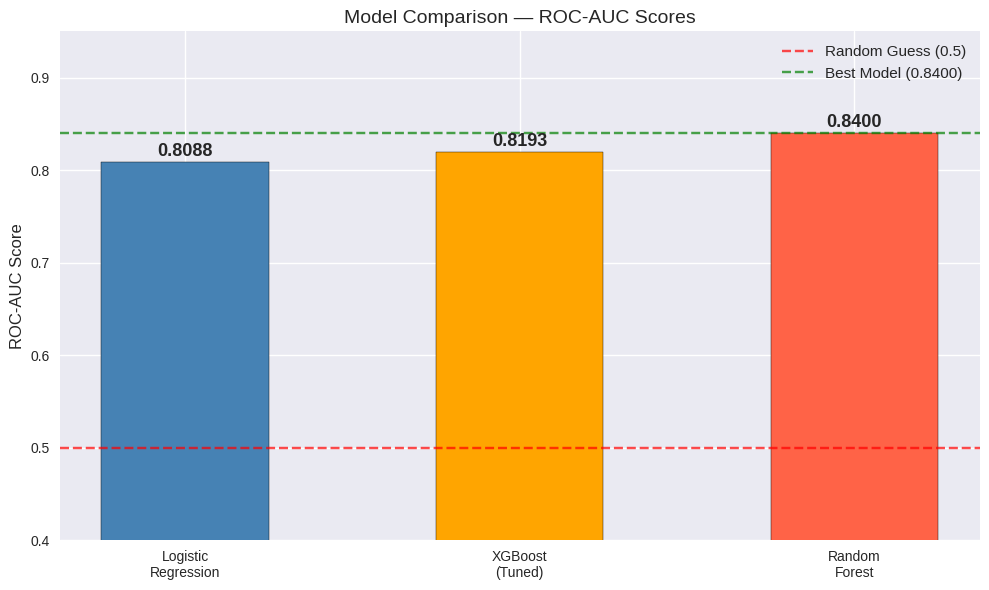

In [37]:
# Block 28 — Final model comparison visualization
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic\nRegression', 'XGBoost\n(Tuned)', 'Random\nForest']
auc_scores = [lr_auc, xgb_auc_v2, rf_auc]
colors = ['steelblue', 'orange', 'tomato']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(models, auc_scores, color=colors,
              edgecolor='black', width=0.5)

# Add value labels on bars
for bar, score in zip(bars, auc_scores):
    ax.text(bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.002,
            f'{score:.4f}', ha='center', va='bottom',
            fontsize=13, fontweight='bold')

# Add a baseline reference line
ax.axhline(y=0.5, color='red', linestyle='--',
           alpha=0.7, label='Random Guess (0.5)')
ax.axhline(y=rf_auc, color='green', linestyle='--',
           alpha=0.7, label=f'Best Model ({rf_auc:.4f})')

ax.set_title('Model Comparison — ROC-AUC Scores', fontsize=14)
ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_ylim(0.4, 0.95)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Block 29 — Save the best model
import joblib

# Save Random Forest model
joblib.dump(rf_model,
            '/content/drive/MyDrive/Credit_Risk_Project/best_model.pkl')

# Save the scaler too (needed for future predictions)
joblib.dump(scaler,
            '/content/drive/MyDrive/Credit_Risk_Project/scaler.pkl')

print("Best model saved ✅")
print("Scaler saved ✅")
print("\nWinner: Random Forest with ROC-AUC =", round(rf_auc, 4))

Best model saved ✅
Scaler saved ✅

Winner: Random Forest with ROC-AUC = 0.84


In [39]:
# Block 30 — Install and setup SHAP
!pip install shap -q

import shap
print("SHAP installed ✅")

# Create SHAP explainer using our Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for test set
# Using 1000 samples — full test set takes too long
X_test_sample = X_test.iloc[:1000]
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated ✅")
print("Shape of SHAP values:", np.array(shap_values).shape)

SHAP installed ✅
SHAP values calculated ✅
Shape of SHAP values: (1000, 16, 2)


In [41]:
# Block 31a — Debug SHAP shape
print("Type of shap_values:", type(shap_values))
print("Length:", len(shap_values))
print("Shape of shap_values[0]:", np.array(shap_values[0]).shape)
print("Shape of shap_values[1]:", np.array(shap_values[1]).shape)
print("X_test_sample shape:", X_test_sample.shape)

Type of shap_values: <class 'numpy.ndarray'>
Length: 1000
Shape of shap_values[0]: (16, 2)
Shape of shap_values[1]: (16, 2)
X_test_sample shape: (1000, 16)


In [43]:
# Block 31 Fixed — Extract correct SHAP values
# shap_values[:, :, 1] means:
# : → all 1000 customers
# : → all 16 features
# 1 → class 1 (Default class — what we care about)

shap_vals_default = shap_values[:, :, 1]
print("Corrected SHAP values shape:", shap_vals_default.shape)
# Should print (1000, 16) — that's what we need

Corrected SHAP values shape: (1000, 16)


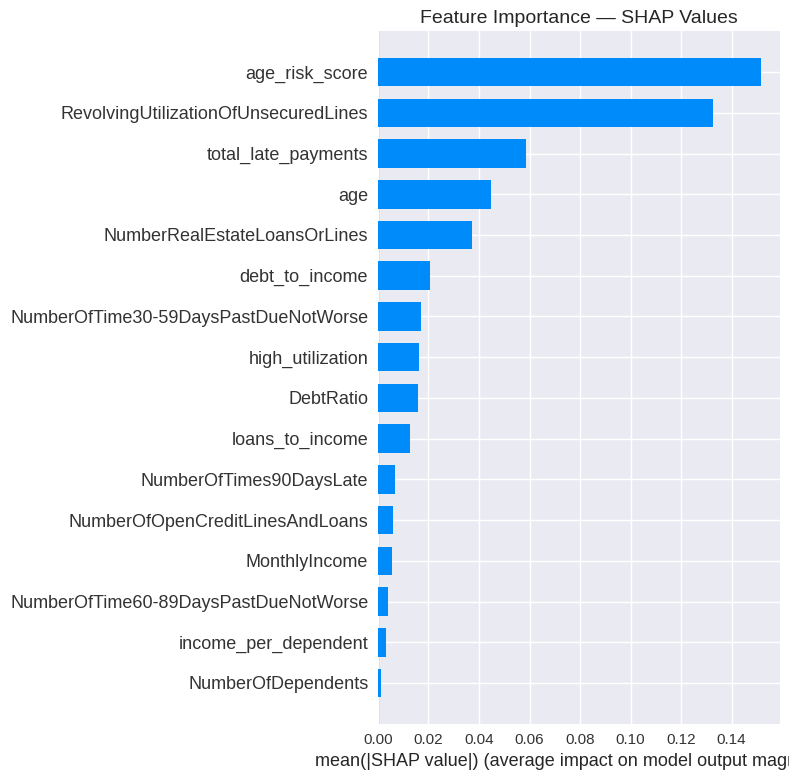

In [44]:
# Block 32 — Feature Importance Bar Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals_default,
    X_test_sample,
    plot_type='bar',
    show=False
)
plt.title('Feature Importance — SHAP Values', fontsize=14)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

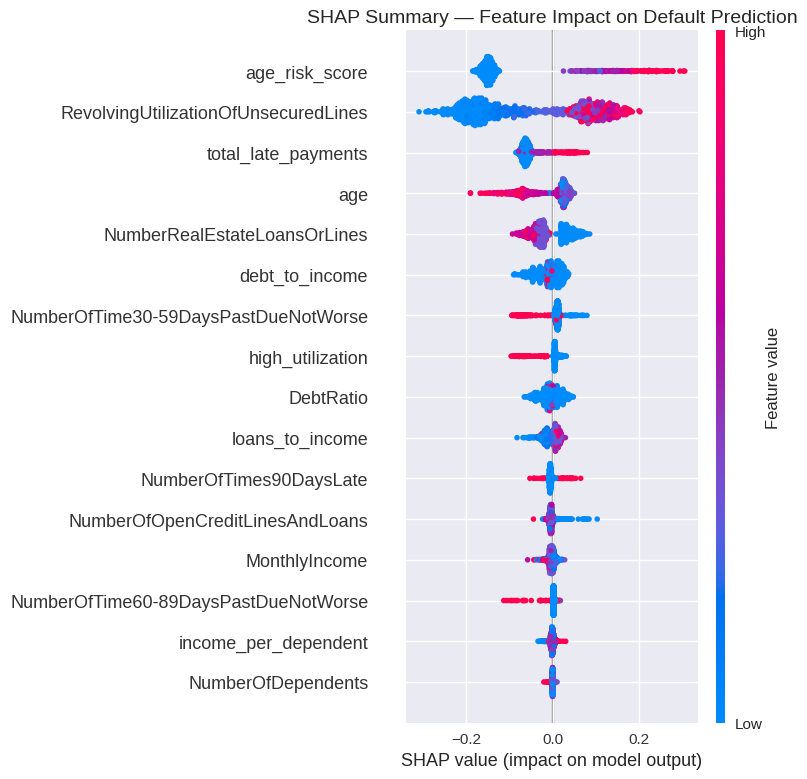

In [45]:
# Block 33 — SHAP Dot Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals_default,
    X_test_sample,
    show=False
)
plt.title('SHAP Summary — Feature Impact on Default Prediction', fontsize=14)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# Block 34 — Explain ONE specific customer
customer_idx = 5
customer = X_test_sample.iloc[[customer_idx]]
customer_shap = shap_vals_default[customer_idx]

print("=" * 55)
print(f"EXPLAINING PREDICTION FOR CUSTOMER #{customer_idx}")
print("=" * 55)
print(f"\nActual Default Status: {y_test.iloc[customer_idx]}")
print(f"Model Predicted Probability: {rf_probs[customer_idx]:.2%}")
print("\nTop factors affecting this customer's risk:")
print("-" * 55)

feature_contributions = list(zip(X_test.columns,
                                  customer_shap,
                                  customer.values[0]))

feature_contributions.sort(key=lambda x: abs(x[1]), reverse=True)

for feature, shap_val, actual_val in feature_contributions[:8]:
    direction = "↑ INCREASES risk" if shap_val > 0 else "↓ DECREASES risk"
    print(f"{feature:40s} = {actual_val:8.2f}  |  {direction} ({shap_val:+.4f})")

EXPLAINING PREDICTION FOR CUSTOMER #5

Actual Default Status: 0
Model Predicted Probability: 7.62%

Top factors affecting this customer's risk:
-------------------------------------------------------
RevolvingUtilizationOfUnsecuredLines     =     0.05  |  ↓ DECREASES risk (-0.1653)
age_risk_score                           =     0.00  |  ↓ DECREASES risk (-0.1442)
total_late_payments                      =     0.00  |  ↓ DECREASES risk (-0.0610)
age                                      =    60.00  |  ↓ DECREASES risk (-0.0524)
NumberRealEstateLoansOrLines             =     2.00  |  ↓ DECREASES risk (-0.0393)
NumberOfTime30-59DaysPastDueNotWorse     =     0.00  |  ↑ INCREASES risk (+0.0149)
loans_to_income                          =     0.00  |  ↑ INCREASES risk (+0.0112)
debt_to_income                           =     0.00  |  ↑ INCREASES risk (+0.0112)


In [47]:
# EMERGENCY SAVE — Run this RIGHT NOW
import joblib



# Save the cleaned featured data
df.to_csv('/content/drive/MyDrive/Credit_Risk_Project/featured_data.csv',
          index=False)

print("Everything saved ✅")

Everything saved ✅


In [48]:
# Check if model is still loaded
try:
    print(rf_model)
    print("✅ Same session — everything still loaded, ready to go!")
except:
    print("❌ New session — need to reload everything first")

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)
✅ Same session — everything still loaded, ready to go!


In [50]:
# Block 35 — Save feature names
# Streamlit app needs to know exact column names and order

import joblib
import json

# Save feature column names
feature_names = X_test.columns.tolist()

with open('/content/drive/MyDrive/Credit_Risk_Project/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("Feature names saved ✅")
print("\nFeatures the app will use:")
for i, f in enumerate(feature_names):
    print(f"  {i+1}. {f}")

Feature names saved ✅

Features the app will use:
  1. RevolvingUtilizationOfUnsecuredLines
  2. age
  3. NumberOfTime30-59DaysPastDueNotWorse
  4. DebtRatio
  5. MonthlyIncome
  6. NumberOfOpenCreditLinesAndLoans
  7. NumberOfTimes90DaysLate
  8. NumberRealEstateLoansOrLines
  9. NumberOfTime60-89DaysPastDueNotWorse
  10. NumberOfDependents
  11. total_late_payments
  12. debt_to_income
  13. income_per_dependent
  14. high_utilization
  15. age_risk_score
  16. loans_to_income


In [52]:
# Block 36 — Write complete Streamlit app to Google Drive

app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import json
import shap
import matplotlib.pyplot as plt

# ─────────────────────────────────────────
# PAGE CONFIG
# ─────────────────────────────────────────
st.set_page_config(
    page_title="Credit Risk Predictor",
    page_icon="🏦",
    layout="wide"
)

# ─────────────────────────────────────────
# LOAD MODEL AND SCALER
# ─────────────────────────────────────────
@st.cache_resource
def load_model():
    model = joblib.load("best_model.pkl")
    scaler = joblib.load("scaler.pkl")
    return model, scaler

model, scaler = load_model()

# ─────────────────────────────────────────
# HEADER
# ─────────────────────────────────────────
st.title("🏦 Credit Risk Assessment System")
st.markdown("### Predict customer default probability using Machine Learning")
st.markdown("---")

# ─────────────────────────────────────────
# SIDEBAR — CUSTOMER INPUT
# ─────────────────────────────────────────
st.sidebar.header("📋 Enter Customer Details")
st.sidebar.markdown("Fill in the customer information below:")

age = st.sidebar.slider(
    "Age",
    min_value=18, max_value=100, value=35,
    help="Customer age in years"
)

monthly_income = st.sidebar.number_input(
    "Monthly Income ($)",
    min_value=0, max_value=25000, value=5000, step=100,
    help="Customer monthly income"
)

revolving_utilization = st.sidebar.slider(
    "Credit Utilization Rate",
    min_value=0.0, max_value=1.0, value=0.3, step=0.01,
    help="How much of credit limit is being used (0 = 0%, 1 = 100%)"
)

debt_ratio = st.sidebar.slider(
    "Debt Ratio",
    min_value=0.0, max_value=1.0, value=0.3, step=0.01,
    help="Monthly debt payments divided by monthly income"
)

num_open_loans = st.sidebar.slider(
    "Number of Open Loans & Credit Lines",
    min_value=0, max_value=30, value=5,
    help="Total number of open credit lines and loans"
)

num_real_estate_loans = st.sidebar.slider(
    "Number of Real Estate Loans",
    min_value=0, max_value=10, value=1,
    help="Number of mortgage and real estate loans"
)

num_dependents = st.sidebar.slider(
    "Number of Dependents",
    min_value=0, max_value=10, value=0,
    help="Number of dependents (family members relying on customer)"
)

st.sidebar.markdown("### Late Payment History")

late_30_59 = st.sidebar.slider(
    "Times 30-59 Days Late",
    min_value=0, max_value=10, value=0,
    help="Number of times 30-59 days past due"
)

late_60_89 = st.sidebar.slider(
    "Times 60-89 Days Late",
    min_value=0, max_value=10, value=0,
    help="Number of times 60-89 days past due"
)

late_90 = st.sidebar.slider(
    "Times 90+ Days Late",
    min_value=0, max_value=10, value=0,
    help="Number of times 90+ days past due"
)

# ─────────────────────────────────────────
# FEATURE ENGINEERING (automatic)
# ─────────────────────────────────────────
def engineer_features(age, monthly_income, revolving_utilization,
                       debt_ratio, num_open_loans, num_real_estate_loans,
                       num_dependents, late_30_59, late_60_89, late_90):

    total_late = late_30_59 + late_60_89 + late_90
    debt_to_income = debt_ratio / (monthly_income + 1)
    income_per_dep = monthly_income / (num_dependents + 1)
    high_util = 1 if revolving_utilization > 0.75 else 0
    age_risk = age * total_late
    loans_to_inc = num_open_loans / (monthly_income + 1)

    features = {
        "RevolvingUtilizationOfUnsecuredLines": revolving_utilization,
        "age": age,
        "NumberOfTime30-59DaysPastDueNotWorse": late_30_59,
        "DebtRatio": debt_ratio,
        "MonthlyIncome": monthly_income,
        "NumberOfOpenCreditLinesAndLoans": num_open_loans,
        "NumberOfTimes90DaysLate": late_90,
        "NumberRealEstateLoansOrLines": num_real_estate_loans,
        "NumberOfTime60-89DaysPastDueNotWorse": late_60_89,
        "NumberOfDependents": num_dependents,
        "total_late_payments": total_late,
        "debt_to_income": debt_to_income,
        "income_per_dependent": income_per_dep,
        "high_utilization": high_util,
        "age_risk_score": age_risk,
        "loans_to_income": loans_to_inc
    }

    return pd.DataFrame([features])

# ─────────────────────────────────────────
# PREDICTION BUTTON
# ─────────────────────────────────────────
st.markdown("## 🎯 Risk Assessment Result")

if st.button("🔍 Predict Default Risk", type="primary", use_container_width=True):

    # Build feature dataframe
    input_df = engineer_features(
        age, monthly_income, revolving_utilization,
        debt_ratio, num_open_loans, num_real_estate_loans,
        num_dependents, late_30_59, late_60_89, late_90
    )

    # Predict
    prob = model.predict_proba(input_df)[0][1]
    prob_pct = prob * 100

    # Risk category
    if prob_pct < 20:
        risk_level = "LOW RISK"
        color = "🟢"
        recommendation = "APPROVE"
        rec_color = "green"
    elif prob_pct < 50:
        risk_level = "MEDIUM RISK"
        color = "🟡"
        recommendation = "MANUAL REVIEW"
        rec_color = "orange"
    else:
        risk_level = "HIGH RISK"
        color = "🔴"
        recommendation = "REJECT"
        rec_color = "red"

    # ── Results Layout ──
    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(
            label="Default Probability",
            value=f"{prob_pct:.1f}%"
        )

    with col2:
        st.metric(
            label="Risk Level",
            value=f"{color} {risk_level}"
        )

    with col3:
        st.metric(
            label="Recommendation",
            value=recommendation
        )

    # ── Risk Bar ──
    st.markdown("### Risk Probability Gauge")
    st.progress(int(prob_pct))

    # ── Customer Summary ──
    st.markdown("---")
    st.markdown("### 📊 Customer Profile Summary")

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("**Personal Details**")
        st.write(f"- Age: {age} years")
        st.write(f"- Monthly Income: ${monthly_income:,}")
        st.write(f"- Number of Dependents: {num_dependents}")
        st.write(f"- Real Estate Loans: {num_real_estate_loans}")

    with col2:
        st.markdown("**Financial Behavior**")
        st.write(f"- Credit Utilization: {revolving_utilization*100:.0f}%")
        st.write(f"- Debt Ratio: {debt_ratio:.2f}")
        st.write(f"- Total Late Payments: {late_30_59 + late_60_89 + late_90}")
        st.write(f"- Open Loans & Credit Lines: {num_open_loans}")

    # ── Key Risk Factors ──
    st.markdown("---")
    st.markdown("### ⚠️ Key Risk Factors")

    total_late = late_30_59 + late_60_89 + late_90

    factors = []
    if revolving_utilization > 0.75:
        factors.append(f"🔴 Very high credit utilization ({revolving_utilization*100:.0f}%)")
    if total_late > 0:
        factors.append(f"🔴 History of late payments ({total_late} times total)")
    if age < 30:
        factors.append(f"🟡 Young age increases risk ({age} years)")
    if monthly_income < 3000:
        factors.append(f"🟡 Low monthly income (${monthly_income:,})")
    if debt_ratio > 0.5:
        factors.append(f"🟡 High debt ratio ({debt_ratio:.2f})")

    if factors:
        for f in factors:
            st.write(f)
    else:
        st.write("🟢 No major risk factors identified — customer appears financially stable")

    # ── Disclaimer ──
    st.markdown("---")
    st.caption(
        "⚠️ This prediction is generated by a machine learning model trained on historical data. "
        "It is intended to assist — not replace — human judgment in credit decisions."
    )

else:
    st.info("👈 Fill in the customer details in the sidebar and click **Predict Default Risk**")

    # Show sample stats while waiting
    st.markdown("### 📈 About This Model")
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Model", "Random Forest")
    col2.metric("ROC-AUC Score", "0.84")
    col3.metric("Training Data", "149,735 customers")
    col4.metric("Features Used", "16")
'''

# Save app.py to Google Drive
with open('/content/drive/MyDrive/Credit_Risk_Project/app.py', 'w') as f:
    f.write(app_code)

print("app.py saved to Google Drive ✅")
print("\nNext steps:")
print("1. Create GitHub repository")
print("2. Upload these files to GitHub:")
print("   - app.py")
print("   - best_model.pkl")
print("   - scaler.pkl")
print("   - requirements.txt (we'll create this next)")

app.py saved to Google Drive ✅

Next steps:
1. Create GitHub repository
2. Upload these files to GitHub:
   - app.py
   - best_model.pkl
   - scaler.pkl
   - requirements.txt (we'll create this next)


In [53]:
# Block 37 — Create requirements.txt
requirements = '''streamlit==1.32.0
pandas==2.0.3
numpy==1.24.3
scikit-learn==1.3.0
xgboost==2.0.3
shap==0.44.0
joblib==1.3.2
matplotlib==3.7.2
'''

with open('/content/drive/MyDrive/Credit_Risk_Project/requirements.txt', 'w') as f:
    f.write(requirements)

print("requirements.txt saved ✅")

requirements.txt saved ✅
